In [29]:
import cv2
from matplotlib import pyplot
import numpy
from scipy.fftpack import dct
from scipy.fftpack import idct
import struct
import zlib

# Zadanie 1

In [30]:
import cv2
from matplotlib import pyplot
import numpy

#
# PPM file header
#
ppm_ascii_header = f'P3\n100 50\n255\n' #plik tekstowy, szerokoscxwysokosc, paleta odcieni
ppm_binary_header = f'P6\n100 50\n255\n' #plik binarny, ...

#
# Image data
#
image = numpy.tile(numpy.array([0, 0, 255], dtype=numpy.uint8), 100*50)


#
# Save the PPM image as an ASCII file
#
with open('lab4-ascii.ppm', 'w') as fh:
    fh.write(ppm_ascii_header)
    image.tofile(fh, sep=' ')
    fh.write('\n')

#
# Save the PPM image as a binary file
#
with open('lab4-binary.ppm', 'wb') as fh:
    fh.write(bytearray(ppm_binary_header, 'ascii'))
    image.tofile(fh)

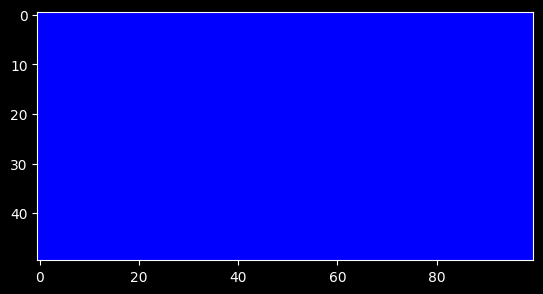

In [31]:
#
# Display image
#
image_from_file = cv2.imread('lab4-ascii.ppm')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

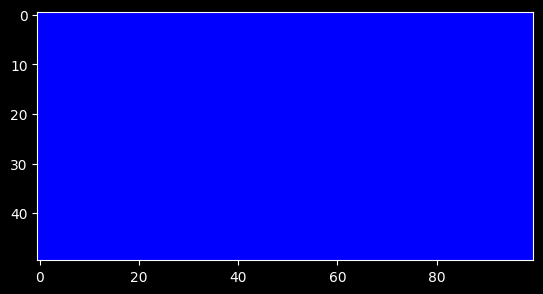

In [32]:
#
# Display image
#
image_from_file = cv2.imread('lab4-binary.ppm')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Zadanie 2

In [33]:
import cv2
from matplotlib import pyplot
import numpy

#
# PPM file header
#
width = 7*256
height = 50
ppm_binary_header = f'P6\n{width} {height}\n255\n'

row = []

for i in range(256):
    row.extend([0, 0, i])

for i in range(256):
    row.extend([0, i, 255])

for i in range(256):
    row.extend([0, 255, 255 - i])

for i in range(256):
    row.extend([i, 255, 0])

for i in range(256):
    row.extend([255, 255 - i, 0])

for i in range(256):
    row.extend([255, 0, i])

for i in range(256):
    row.extend([255, i, 255])
#
# Image data
#
row = numpy.array(row, dtype=numpy.uint8)
image = numpy.tile(row, height)

#
# Save the PPM image as a binary file
#
with open('lab4-rainbow.ppm', 'wb') as fh:
    fh.write(bytearray(ppm_binary_header, 'ascii'))
    image.tofile(fh)

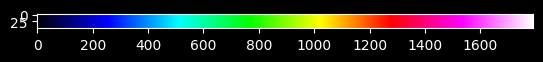

In [34]:
#
# Display image
#
image_from_file = cv2.imread('lab4-rainbow.ppm')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Zadanie 3

In [35]:
import cv2
from matplotlib import pyplot
import numpy
import struct
import zlib
#
# Image data
#
height = 100

row = []

for i in range(256):
    row.append([0, 0, i])

for i in range(256):
    row.append([0, i, 255])

for i in range(256):
    row.append([0, 255, 255 - i])

for i in range(256):
    row.append([i, 255, 0])

for i in range(256):
    row.append([255, 255 - i, 0])

for i in range(256):
    row.append([255, 0, i])

for i in range(256):
    row.append([255, i, 255])

row = numpy.array(row, dtype=numpy.uint8)
image = numpy.tile(row[numpy.newaxis, :, :], (height, 1, 1))

#
# Construct signature
#
png_file_signature = b'\x89\x50\x4E\x47\x0D\x0A\x1A\x0A'

#
# Construct header
#
height, width = image.shape[:2]

header_id = b'IHDR' #image header
header_content = struct.pack('!IIBBBBB', width, height, 8, 2, 0, 0, 0) #szerokosc, wysokosc, glebia koloru, typ koloru RGB (bez przezroczystosci), metoda kompresji, metoda filtrowania, przeplot
header_size = struct.pack('!I', len(header_content))
header_crc = struct.pack('!I', zlib.crc32(header_id + header_content) & 0xffffffff)
png_file_header = header_size + header_id + header_content + header_crc

#
# Construct data
#
data_id = b'IDAT' #image data
raw_data = b''.join([b'\x00' + row.tobytes() for row in image])
data_content = zlib.compress(raw_data)
data_size = struct.pack('!I', len(data_content))
data_crc = struct.pack('!I', zlib.crc32(data_id + data_content) & 0xffffffff)
png_file_data = data_size + data_id + data_content + data_crc

#
# Consruct end
#
end_id = b'IEND'
end_content = b''
end_size = struct.pack('!I', len(end_content))
end_crc = struct.pack('!I', zlib.crc32(end_id + end_content))
png_file_end = end_size + end_id + end_content + end_crc

#
# Save the PNG image as a binary file
#
with open('lab4.png', 'wb') as fh:
    fh.write(png_file_signature)
    fh.write(png_file_header)
    fh.write(png_file_data)
    fh.write(png_file_end)


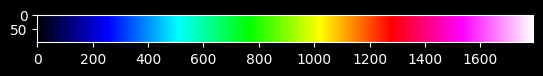

In [36]:
#
# Display image
#
image_from_file = cv2.imread('lab4.png')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Funkcje pomocnicze do zadań 4 i 5

In [37]:
#
# 2d Discrete Cosinus Transform
#
def dct2(array):
    return dct(dct(array, axis=0, norm='ortho'), axis=1, norm='ortho')


def idct2(array):
    return idct(idct(array, axis=0, norm='ortho'), axis=1, norm='ortho')


#
# Calculate quantisation matrices
#
# Based on: https://www.hdm-stuttgart.de/~maucher/Python/MMCodecs/html/jpegUpToQuant.html
#           #step-3-and-4-discrete-cosinus-transform-and-quantisation
#
_QY = numpy.array([[16, 11, 10, 16, 24, 40, 51, 61],
                   [12, 12, 14, 19, 26, 48, 60, 55],
                   [14, 13, 16, 24, 40, 57, 69, 56],
                   [14, 17, 22, 29, 51, 87, 80, 62],
                   [18, 22, 37, 56, 68, 109, 103, 77],
                   [24, 35, 55, 64, 81, 104, 113, 92],
                   [49, 64, 78, 87, 103, 121, 120, 101],
                   [72, 92, 95, 98, 112, 100, 103, 99]])

_QC = numpy.array([[17, 18, 24, 47, 99, 99, 99, 99],
                   [18, 21, 26, 66, 99, 99, 99, 99],
                   [24, 26, 56, 99, 99, 99, 99, 99],
                   [47, 66, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99],
                   [99, 99, 99, 99, 99, 99, 99, 99]])


def _scale(QF):
    if QF < 50 and QF >= 1:
        scale = numpy.floor(5000 / QF)
    elif QF < 100:
        scale = 200 - 2 * QF
    else:
        raise ValueError('Quality Factor must be in the range [1..99]')

    scale = scale / 100.0
    return scale


def QY(QF=85):
    return _QY * _scale(QF)


def QC(QF=85):
    return _QC * _scale(QF)

def zigzag_indices(n=8):
    order = []

    for s in range(2 * n - 1):
        if s % 2 == 0:
            i_start = min(s, n - 1)
            i_end = max(-1, s - n)
            for i in range(i_start, i_end, -1):
                j = s - i
                order.append((i, j))
        else:
            j_start = min(s, n - 1)
            j_end = max(-1, s - n)
            for j in range(j_start, j_end, -1):
                i = s - j
                order.append((i, j))

    return order


ZIGZAG_ORDER = zigzag_indices(8)


def zigzag(block):
    return numpy.array([block[i, j] for i, j in ZIGZAG_ORDER], dtype=block.dtype)

# Zadania 4 i 5

In [38]:
import numpy
import cv2
import zlib
from scipy.fftpack import dct, idct
from matplotlib import pyplot


sampling_step = 2
QF = 20


#
# 0. Image data
#
height = 50
row = []

for i in range(256):
    row.append([0, 0, i])

for i in range(256):
    row.append([0, i, 255])

for i in range(256):
    row.append([0, 255, 255 - i])

for i in range(256):
    row.append([i, 255, 0])

for i in range(256):
    row.append([255, 255 - i, 0])

for i in range(256):
    row.append([255, 0, i])

for i in range(256):
    row.append([255, i, 255])

row = numpy.array(row, dtype=numpy.uint8)
image = numpy.tile(row[numpy.newaxis, :, :], (height, 1, 1))
image_float = image.astype(numpy.float32)

#
# 1. Convert RGB to YCbCr
#
matrix1 = numpy.array([0, 128, 128], dtype=numpy.float32)
matrix2 = numpy.array([
    [0.299, 0.587, 0.114], #y
    [0.500, -0.418, -0.082], #cr
    [-0.168, -0.331, 0.500], #cb
], dtype=numpy.float32)

transformed_image = image_float @ matrix2.T + matrix1

Y  = transformed_image[:, :, 0]
Cr = transformed_image[:, :, 1]
Cb = transformed_image[:, :, 2]

#
# 2. Downsampling on Cb and Cr channels
#
Cb_down = Cb[::sampling_step, ::sampling_step]
Cr_down = Cr[::sampling_step, ::sampling_step]

#
# 3. Produce 8x8 blocks
#

# oryginalne rozmiary
Y_original_shape = Y.shape
Cb_original_shape = Cb_down.shape
Cr_original_shape = Cr_down.shape

# ile trzeba dopelnic do wielokrotnosci 8
Y_pad_h = (8 - Y.shape[0] % 8) % 8
Y_pad_w = (8 - Y.shape[1] % 8) % 8

Cb_pad_h = (8 - Cb_down.shape[0] % 8) % 8
Cb_pad_w = (8 - Cb_down.shape[1] % 8) % 8

Cr_pad_h = (8 - Cr_down.shape[0] % 8) % 8
Cr_pad_w = (8 - Cr_down.shape[1] % 8) % 8

# dopelnianie macierzy
Y_padded = numpy.pad(Y, ((0, Y_pad_h), (0, Y_pad_w)), mode='edge') #dodawanie wierszy na dole i kolumn z prawej
Cb_padded = numpy.pad(Cb_down, ((0, Cb_pad_h), (0, Cb_pad_w)), mode='edge')
Cr_padded = numpy.pad(Cr_down, ((0, Cr_pad_h), (0, Cr_pad_w)), mode='edge')

# rozmiary po dopelnieniu
Y_padded_shape = Y_padded.shape
Cb_padded_shape = Cb_padded.shape
Cr_padded_shape = Cr_padded.shape

# lista blokow 8x8 dla Y
Y_blocks = []
for y in range(0, Y_padded.shape[0], 8):
    for x in range(0, Y_padded.shape[1], 8):
        block = Y_padded[y:y+8, x:x+8].copy()
        Y_blocks.append(block)

# lista blokow 8x8 dla Cb
Cb_blocks = []
for y in range(0, Cb_padded.shape[0], 8):
    for x in range(0, Cb_padded.shape[1], 8):
        block = Cb_padded[y:y+8, x:x+8].copy()
        Cb_blocks.append(block)

# lista blokow 8x8 dla Cr
Cr_blocks = []
for y in range(0, Cr_padded.shape[0], 8):
    for x in range(0, Cr_padded.shape[1], 8):
        block = Cr_padded[y:y+8, x:x+8].copy()
        Cr_blocks.append(block)

#
# 4. Calculate DCT on each block
#
Y_blocks_dct = []
for block in Y_blocks:
    Y_blocks_dct.append(dct2(block - 128.0))

Cb_blocks_dct = []
for block in Cb_blocks:
    Cb_blocks_dct.append(dct2(block - 128.0))

Cr_blocks_dct = []
for block in Cr_blocks:
    Cr_blocks_dct.append(dct2(block - 128.0))

#
# 5. Divide each block by quantisation matrix
#
QY_matrix = QY(QF)
QC_matrix = QC(QF)

Y_blocks_quant = []
for block in Y_blocks_dct:
    Y_blocks_quant.append(block / QY_matrix)

Cb_blocks_quant = []
for block in Cb_blocks_dct:
    Cb_blocks_quant.append(block / QC_matrix)

Cr_blocks_quant = []
for block in Cr_blocks_dct:
    Cr_blocks_quant.append(block / QC_matrix)

#
# 6. Round values in each block to integers
#
Y_blocks_round = []
for block in Y_blocks_quant:
    Y_blocks_round.append(numpy.rint(block).astype(numpy.int16))

Cb_blocks_round = []
for block in Cb_blocks_quant:
    Cb_blocks_round.append(numpy.rint(block).astype(numpy.int16))

Cr_blocks_round = []
for block in Cr_blocks_quant:
    Cr_blocks_round.append(numpy.rint(block).astype(numpy.int16))

#
# 7. Zig Zag
#
Y_zigzag = []
for block in Y_blocks_round:
    Y_zigzag.append(zigzag(block))

Cb_zigzag = []
for block in Cb_blocks_round:
    Cb_zigzag.append(zigzag(block))

Cr_zigzag = []
for block in Cr_blocks_round:
    Cr_zigzag.append(zigzag(block))

#
# 8. Flatten, concatenate, compress and calculate the size -- how many bytes?
#
encoded_stream = numpy.concatenate([
    numpy.concatenate(Y_zigzag),
    numpy.concatenate(Cb_zigzag),
    numpy.concatenate(Cr_zigzag)
]).astype(numpy.int16)

compressed_stream = zlib.compress(encoded_stream.tobytes())

print('sampling_step =', sampling_step)
print('QF =', QF)
print('Rozmiar po kompresji [B]:', len(compressed_stream))

#
# 7'. Undo Zig Zag
#
# We can skip it in this exercise! We did Zig Zag only for analysis in step 8.
# You can continue with result from step 6. instead of implementing undo here.
#

#
# 6'. Nothing to do here   ¯\_(ツ)_/¯
#
# No conversion is really needed here, just proceed to the next step.
#

#
# 5'. Reverse division by quantisation matrix -- multiply
#
Y_blocks_dequant = []
for block in Y_blocks_round:
    Y_blocks_dequant.append(block.astype(numpy.float32) * QY_matrix)

Cb_blocks_dequant = []
for block in Cb_blocks_round:
    Cb_blocks_dequant.append(block.astype(numpy.float32) * QC_matrix)

Cr_blocks_dequant = []
for block in Cr_blocks_round:
    Cr_blocks_dequant.append(block.astype(numpy.float32) * QC_matrix)

#
# 4'. Reverse DCT
#
Y_blocks_reconstructed = []
for block in Y_blocks_dequant:
    Y_blocks_reconstructed.append(idct2(block) + 128.0)

Cb_blocks_reconstructed = []
for block in Cb_blocks_dequant:
    Cb_blocks_reconstructed.append(idct2(block) + 128.0)

Cr_blocks_reconstructed = []
for block in Cr_blocks_dequant:
    Cr_blocks_reconstructed.append(idct2(block) + 128.0)

#
# 3'. Combine 8x8 blocks to original image
#
Y_full = numpy.zeros(Y_padded_shape, dtype=numpy.float32)
idx = 0
for y in range(0, Y_padded_shape[0], 8):
    for x in range(0, Y_padded_shape[1], 8):
        Y_full[y:y+8, x:x+8] = Y_blocks_reconstructed[idx]
        idx += 1
Y_reconstructed = Y_full[:Y_original_shape[0], :Y_original_shape[1]]

Cb_full = numpy.zeros(Cb_padded_shape, dtype=numpy.float32)
idx = 0
for y in range(0, Cb_padded_shape[0], 8):
    for x in range(0, Cb_padded_shape[1], 8):
        Cb_full[y:y+8, x:x+8] = Cb_blocks_reconstructed[idx]
        idx += 1
Cb_down_reconstructed = Cb_full[:Cb_original_shape[0], :Cb_original_shape[1]]

Cr_full = numpy.zeros(Cr_padded_shape, dtype=numpy.float32)
idx = 0
for y in range(0, Cr_padded_shape[0], 8):
    for x in range(0, Cr_padded_shape[1], 8):
        Cr_full[y:y+8, x:x+8] = Cr_blocks_reconstructed[idx]
        idx += 1
Cr_down_reconstructed = Cr_full[:Cr_original_shape[0], :Cr_original_shape[1]]

#
# 2'. Upsampling on Cb and Cr channels
#
Cb_reconstructed = Cb_down_reconstructed.repeat(sampling_step, axis=0).repeat(sampling_step, axis=1)
Cr_reconstructed = Cr_down_reconstructed.repeat(sampling_step, axis=0).repeat(sampling_step, axis=1)

Cb_reconstructed = Cb_reconstructed[:Y_reconstructed.shape[0], :Y_reconstructed.shape[1]]
Cr_reconstructed = Cr_reconstructed[:Y_reconstructed.shape[0], :Y_reconstructed.shape[1]]

#
# 1'. Convert YCbCr to RGB
#
Cr_shifted = Cr_reconstructed - 128.0
Cb_shifted = Cb_reconstructed - 128.0

R = 0.999998 * Y_reconstructed + 1.402687 * Cr_shifted + 0.002041 * Cb_shifted
G = 1.000345 * Y_reconstructed - 0.714196 * Cr_shifted - 0.345207 * Cb_shifted
B = 0.998228 * Y_reconstructed - 0.001495 * Cr_shifted + 1.772159 * Cb_shifted

decoded_image = numpy.stack([R, G, B], axis=2)
decoded_image = numpy.clip(numpy.rint(decoded_image), 0, 255).astype(numpy.uint8)

mse = numpy.mean((image.astype(numpy.float32) - decoded_image.astype(numpy.float32)) ** 2)
print('MSE =', mse)

#
# 0'. Save the decoded image -- as PPM or PNG
#
cv2.imwrite(
    'lab4-po-kompresji-i-dekompresji-jpeg.png',
    cv2.cvtColor(decoded_image, cv2.COLOR_RGB2BGR)
)

sampling_step = 2
QF = 20
Rozmiar po kompresji [B]: 3370
MSE = 8.412203


True

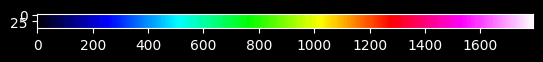

In [39]:
#
# Display image
#
image_from_file = cv2.imread('lab4-po-kompresji-i-dekompresji-jpeg.png')
pyplot.imshow(cv2.cvtColor(image_from_file, cv2.COLOR_BGR2RGB))

# Obserwacje z zadań 4 i 5

In [40]:
'''

sampling_step = 1
QF = 20
Rozmiar po kompresji [B]: 6396
MSE = 6.1220236

sampling_step = 2
QF = 20
Rozmiar po kompresji [B]: 3387
MSE = 9.745536

sampling_step = 4
QF = 20
Rozmiar po kompresji [B]: 2411
MSE = 11.110119

sampling_step = 8
QF = 20
Rozmiar po kompresji [B]: 2164
MSE = 10.431547



sampling_step = 1
QF = 50
Rozmiar po kompresji [B]: 6743
MSE = 1.6888021

sampling_step = 2
QF = 50
Rozmiar po kompresji [B]: 3551
MSE = 1.3485863

sampling_step = 4
QF = 50
Rozmiar po kompresji [B]: 2694
MSE = 1.890625

sampling_step = 8
QF = 50
Rozmiar po kompresji [B]: 2422
MSE = 6.488653


Na podstawie uzyskanych wyników widać że zwiększanie downsamplingu znacząco zmniejsza rozmiar danych po kompresji. Przykładowo dla QF = 20 rozmiar spadł z 6396 B do 2411 B przy przejściu od sampling_step = 1 do sampling_step = 4, a dla QF = 50 z 6743 B do 2694 B. Jednocześnie w większości przypadków rosła wartość MSE, co oznacza pogorszenie jakości obrazu. Widać również, że dla większego QF błędy są znacznie mniejsze niż dla QF = 20, ale rozmiar danych po kompresji jest wtedy większy.
'''

'\n\nsampling_step = 1\nQF = 20\nRozmiar po kompresji [B]: 6396\nMSE = 6.1220236\n\nsampling_step = 2\nQF = 20\nRozmiar po kompresji [B]: 3387\nMSE = 9.745536\n\nsampling_step = 4\nQF = 20\nRozmiar po kompresji [B]: 2411\nMSE = 11.110119\n\nsampling_step = 8\nQF = 20\nRozmiar po kompresji [B]: 2164\nMSE = 10.431547\n\n\n\nsampling_step = 1\nQF = 50\nRozmiar po kompresji [B]: 6743\nMSE = 1.6888021\n\nsampling_step = 2\nQF = 50\nRozmiar po kompresji [B]: 3551\nMSE = 1.3485863\n\nsampling_step = 4\nQF = 50\nRozmiar po kompresji [B]: 2694\nMSE = 1.890625\n\nsampling_step = 8\nQF = 50\nRozmiar po kompresji [B]: 2422\nMSE = 6.488653\n\n\nNa podstawie uzyskanych wyników widać że zwiększanie downsamplingu znacząco zmniejsza rozmiar danych po kompresji. Przykładowo dla QF = 20 rozmiar spadł z 6396 B do 2411 B przy przejściu od sampling_step = 1 do sampling_step = 4, a dla QF = 50 z 6743 B do 2694 B. Jednocześnie w większości przypadków rosła wartość MSE, co oznacza pogorszenie jakości obrazu. W